In [1]:
import tensorflow as tf
import numpy as np
import cv2

In [2]:
def load_image(image_path):
    """
    Load preprocessed image.
    
    """

    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise Exception(f"Could not load image: {image_path}")

    # Convert to float32
    image = image.astype(np.float32)

    # Add grayscale channel to expand dimensions to 244x244x3
    image = np.expand_dims(image, axis=-1)

    # Convert grayscale to RGB
    image = np.repeat(image, 3, axis=-1)

    return image

In [3]:
def create_dataset(image_paths, labels, batch_size=32, shuffle=True):
    images = []

    for path in image_paths:
        image = load_image(path)
        images.append(image)

    images = np.array(images)
    labels = np.array(labels)

    dataset = tf.data.Dataset.from_tensor_slices((images, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(images))

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

In [5]:
import src.ImagesPreprocessorService

In [6]:
( complete_dataset, training_dataset, validation_dataset, testing_dataset) = src.ImagesPreprocessorService.load_processed_dataset()
(X_train, y_train, X_val, y_val, X_test, y_test) = src.ImagesPreprocessorService.get_labeled_datasets(training_dataset, validation_dataset, testing_dataset)

In [7]:
train = create_dataset( X_train, y_train)
val = create_dataset( X_val, y_val, shuffle=False)
test = create_dataset(X_test, y_test, shuffle=False)

In [8]:
from src.models import EfficientNetBinaryClassifier

In [9]:
effNetModel = EfficientNetBinaryClassifier(train_backbone=False)

effNetModel.build((None, 224, 224, 3))

effNetModel.summary()

Model: "efficient_net_binary_classifier"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb0 (Functional)  (None, 7, 7, 1280)       4049571   
                                                                 
 global_average_pooling2d (G  multiple                 0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           multiple                  0         
                                                                 
 dense (Dense)               multiple                  327936    
                                                                 
 dense_1 (Dense)             multiple                  257       
                                                                 
Total params: 4,377,764
Trainable params: 328,193
Non-trainable params: 4,049,571
___________________

In [10]:
effNetModel.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-4
    ),

    loss="binary_crossentropy",

    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [11]:
class_weight = {
    0: 1.5,   # NORMAL
    1: 1.0    # PNEUMONIA
}

history = effNetModel.fit(train, validation_data=val, epochs=10, class_weight=class_weight)

Epoch 1/10
148/148 [==============================] - 26s 104ms/step - loss: 0.3648 - accuracy: 0.8859 - precision: 0.9088 - recall: 0.9408 - val_loss: 0.1778 - val_accuracy: 0.9351 - val_precision: 0.9587 - val_recall: 0.9537
Epoch 2/10
148/148 [==============================] - 12s 79ms/step - loss: 0.1958 - accuracy: 0.9367 - precision: 0.9653 - recall: 0.9488 - val_loss: 0.1379 - val_accuracy: 0.9447 - val_precision: 0.9688 - val_recall: 0.9563
Epoch 3/10
148/148 [==============================] - 12s 79ms/step - loss: 0.1534 - accuracy: 0.9526 - precision: 0.9767 - recall: 0.9591 - val_loss: 0.1243 - val_accuracy: 0.9561 - val_precision: 0.9816 - val_recall: 0.9589
Epoch 4/10
148/148 [==============================] - 12s 78ms/step - loss: 0.1374 - accuracy: 0.9588 - precision: 0.9808 - recall: 0.9634 - val_loss: 0.1081 - val_accuracy: 0.9618 - val_precision: 0.9817 - val_recall: 0.9666
Epoch 5/10
148/148 [==============================] - 12s 80ms/step - loss: 0.1245 - accuracy: 

In [12]:
results = effNetModel.evaluate(test)

print(results)

20/20 [==============================] - 2s 72ms/step - loss: 0.5360 - accuracy: 0.8237 - precision: 0.7823 - recall: 0.9949
[0.5360327959060669, 0.8237179517745972, 0.7822580337524414, 0.9948718547821045]


In [13]:
effNetModel.backbone.summary()

Model: "efficientnetb0"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (Rescaling)        (None, 224, 224, 3)  0           ['normalization[0][0

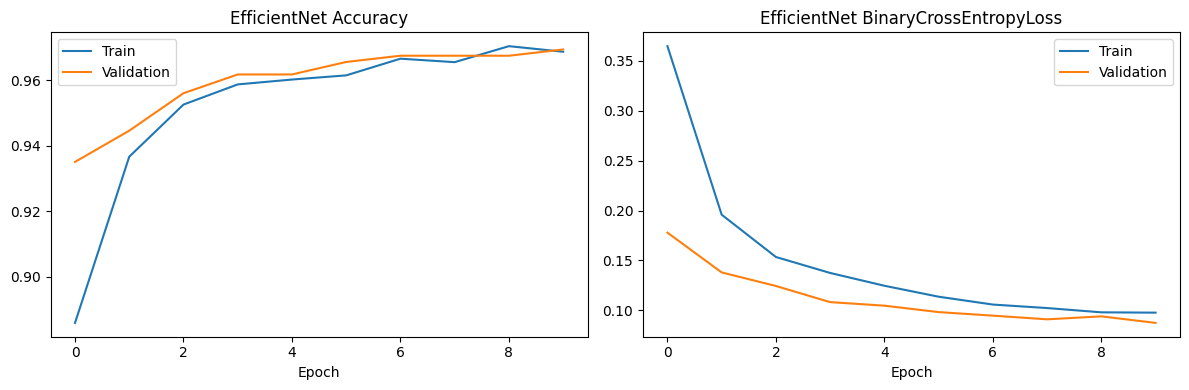

In [14]:
from pathlib import Path
from src.plot import plot_history

FIG_DIR = Path(".") / "outputs" / "EfficientNet"
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = "EfficientNet"

plot_history(history, MODEL_NAME, FIG_DIR / "training_history.png")

20/20 [==============================] - 4s 72ms/step


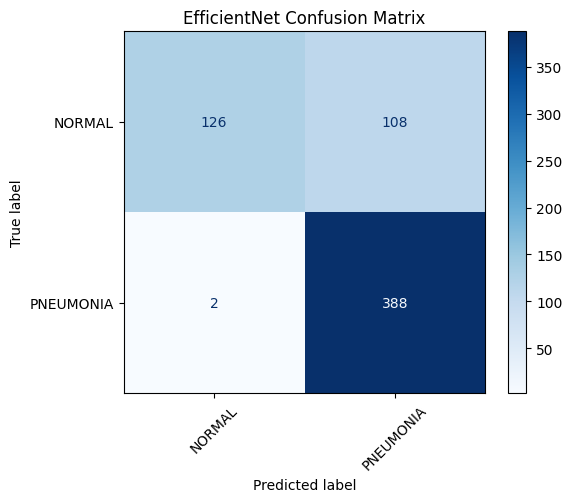

In [15]:
from src.plot import plot_confusion_matrix
from sklearn.metrics import confusion_matrix

CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
DECISION_BOUNDARY = 0.5

y_test_true = np.concatenate([y for _, y in test], axis=0)
y_test_proba = effNetModel.predict(test)
y_test_pred = (y_test_proba > DECISION_BOUNDARY).astype(int).flatten()
cm = confusion_matrix(y_test_true, y_test_pred)

plot_confusion_matrix(cm, CLASS_NAMES, MODEL_NAME, FIG_DIR / "test_confusion_matrix.png")

In [ ]:
from src.plot import plot_roc_curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test_true, y_test_proba)
roc_auc = auc(fpr, tpr)

plot_roc_curve(fpr, tpr, roc_auc, MODEL_NAME, FIG_DIR / "roc_auc.png")